# 05 CNN Image Classification

##  Importing Libraries

We import the libraries and choose the device. If a GPU is available, PyTorch uses it, otherwise it uses the CPU. We also fix the random seed so that the results are the same every time you run the notebook (on the same computer).

In [1]:
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


**Interpretation:** GPU -> `cuda`; otherwise `cpu`. The notebook works on CPU; Fashion-MNIST is fast, while CIFAR-10 is slower.

# Part 1: Baseline with Fashion-MNIST

Fashion-MNIST has 70,000 grayscale pictures (28 x 28 pixels) of 10 kinds of clothes and shoes. It has the same size and format as the MNIST digits, but it is a little harder, so the differences between models are easier to see.

## 1.1 Dataset Loading

**Definition:** Dataset loading means getting the images and their labels into the program. `torchvision.datasets` downloads a dataset once, stores it in a folder, and gives us an object that we can index like a list.

**Example:** `datasets.FashionMNIST(root="data", train=True, download=True)` downloads the 60,000 training images into a folder called `data`, and `train=False` gives the 10,000 test images.

**AI/ML Usage:** Loading data is the first step of every AI/ML pipeline. Standard benchmark datasets such as MNIST, Fashion-MNIST and CIFAR-10 are used to test new ideas and to compare models fairly. In industry the same step reads images from folders, databases or cloud storage, and the loading code is often reused in production.

In [2]:
train_raw = datasets.FashionMNIST(root="data", train=True, download=True)
test_raw = datasets.FashionMNIST(root="data", train=False, download=True)
class_names = train_raw.classes
print("Training images:", len(train_raw))
print("Test images:", len(test_raw))
print("Classes:", class_names)

100%|██████████| 26.4M/26.4M [00:20<00:00, 1.28MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 155kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.84MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.00MB/s]

Training images: 60000
Test images: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


**Interpretation:** There are 60,000 training and 10,000 test samples; labels represent 10 clothing categories.

## 1.2 Dataset Inspection

**Definition:** Inspection means checking the basic facts of the data before building anything: the number of images, the image size, the number of channels, the range of the pixel values, the data type and the labels.

**Example:** For one image we check: Is it 28 x 28? Is it grayscale or colour? Do the pixels go from 0 to 255? Which label does it have?

**AI/ML Usage:** Inspecting the data is a standard first check (part of exploratory data analysis) in every machine learning project. Teams check shapes, data types, value ranges and missing or corrupt files before training, because data problems cause more failures in real AI systems than model problems.

In [3]:
image, label = train_raw[0]
print("One sample type:", type(image).__name__, "| image size:", image.size, "| mode:", image.mode)
print("Label of the first image:", label, "->", class_names[label])
print("Data array shape:", tuple(train_raw.data.shape))
print("Data type:", train_raw.data.dtype)
print("Pixel value range:", train_raw.data.min().item(), "to", train_raw.data.max().item())
train_labels = torch.as_tensor(train_raw.targets).numpy()
print("Images per class:", np.bincount(train_labels))

One sample type: Image | image size: (28, 28) | mode: L
Label of the first image: 9 -> Ankle boot
Data array shape: (60000, 28, 28)
Data type: torch.uint8
Pixel value range: 0 to 255
Images per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


**Interpretation:** Each sample is a 28x28 grayscale image, shaped as a single-channel array.

Class counts are balanced, so evaluation is fair and easy to compare.

## 1.4 Image Visualization

**Definition:** Visualization means looking at real images of the dataset with their labels.

**Example:** We show the first training image of every class in a grid of 2 rows and 5 columns.

**AI/ML Usage:** Data scientists look at sample images to find wrong labels, duplicates, poor quality pictures and bias in the data. Visual checks are also used to decide which augmentations are safe, and to explain results to people who are not technical.

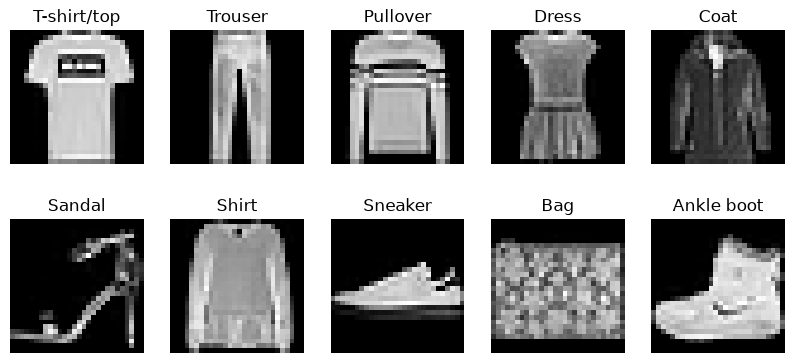

In [4]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))
for i, a in enumerate(ax.flat):
    index = int(np.where(train_labels == i)[0][0])
    a.imshow(train_raw[index][0], cmap="gray")
    a.set_title(class_names[i])
    a.axis("off")
plt.show()

**Interpretation:** The images are centered and simple, so little cropping or resizing is needed.

 Normalizing pixel values helps the model learn smoothly and train faster.

 Random flips/rotations simulate real variations and reduce overfitting.

## 1.7 DataLoader Creation

**Definition:** A `DataLoader` takes a dataset and delivers it in small groups called batches. It can also shuffle the data every epoch. Before that we need three datasets (training, validation, test), each with the right transform.

**Example:** With `batch_size=128` the model receives 128 images at a time, as a tensor of shape (128, 1, 28, 28), together with 128 labels.

**AI/ML Usage:** Batching with data loaders is how all deep learning frameworks feed data to a model. In large projects the loaders read and prepare the data in parallel, so that the GPU never waits for data, and the same idea is used for datasets that are too big to fit in memory.

In [5]:
indices = torch.randperm(len(train_raw))
n_val = len(indices) // 10
train_idx, val_idx = indices[:-n_val], indices[-n_val:]
pixels = torch.as_tensor(train_raw.data)[train_idx].float() / 255
mean, std = pixels.mean().item(), pixels.std().item()
print("Mean and std of the training pixels: %.4f and %.4f" % (mean, std))
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),
])
full_train = datasets.FashionMNIST(root="data", train=True, transform=train_transform)
full_val = datasets.FashionMNIST(root="data", train=True, transform=test_transform)
test_set = datasets.FashionMNIST(root="data", train=False, transform=test_transform)
train_set = Subset(full_train, train_idx)
val_set = Subset(full_val, val_idx)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256)
test_loader = DataLoader(test_set, batch_size=256)
images, labels = next(iter(train_loader))
print("Training / validation / test images:", len(train_set), len(val_set), len(test_set))
print("One batch of images:", tuple(images.shape), "| labels:", tuple(labels.shape))
print("Batch values -> smallest: %.2f, largest: %.2f" % (images.min().item(), images.max().item()))

Mean and std of the training pixels: 0.2863 and 0.3531
Training / validation / test images: 54000 6000 10000
One batch of images: (128, 1, 28, 28) | labels: (128,)
Batch values -> smallest: -0.81, largest: 2.02


**Interpretation:** Training and validation sets are separate, and augmentation is applied only to training images.

## 1.8 CNN Architecture

**Definition:** The architecture is the list of layers of the network. Our CNN has two convolution blocks, each with Convolution, Batch Normalization, ReLU and Max Pooling, followed by a classifier that has Flatten, a fully connected layer, Dropout and an output layer with 10 scores (one per class).

**Example:** The image (1, 28, 28) becomes 32 feature maps of 14 x 14 after the first block, and 64 feature maps of 7 x 7 after the second block. Flatten turns them into 64 x 7 x 7 = 3136 numbers, and the fully connected layers turn them into 10 scores.

**AI/ML Usage:** CNN architectures like this one are the basis of image classification, object detection, face recognition, medical image analysis and many other vision systems. Designing an architecture means balancing accuracy, speed and memory, for example for a phone or an embedded device. Larger CNNs such as ResNet are built from the same blocks.

In [6]:
fashion_model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 10),
)
x = torch.zeros(1, 1, 28, 28)
for layer in fashion_model.eval():
    x = layer(x)
    print(layer.__class__.__name__.ljust(12), tuple(x.shape))
fashion_params = sum(p.numel() for p in fashion_model.parameters())
print("Learnable numbers:", fashion_params)

Conv2d       (1, 32, 28, 28)
BatchNorm2d  (1, 32, 28, 28)
ReLU         (1, 32, 28, 28)
MaxPool2d    (1, 32, 14, 14)
Conv2d       (1, 64, 14, 14)
BatchNorm2d  (1, 64, 14, 14)
ReLU         (1, 64, 14, 14)
MaxPool2d    (1, 64, 7, 7)
Flatten      (1, 3136)
Linear       (1, 128)
ReLU         (1, 128)
Dropout      (1, 128)
Linear       (1, 10)
Learnable numbers: 421834


**Interpretation:** Feature maps shrink as layers deepen; the CNN ends by flattening to 10 class scores.

## 1.9 Training

**Definition:** Training means showing the training images to the network batch by batch and changing its weights to reduce the loss. For every batch we do four steps: (1) the forward pass gives the scores, (2) the loss measures the error with `cross_entropy`, (3) `loss.backward()` finds how each weight should change, and (4) `optimizer.step()` changes the weights. One pass over all the training images is one epoch.

**Example:** With 54,000 images and a batch size of 128, one epoch has about 422 weight updates. We train for 8 epochs with the Adam optimizer.

**AI/ML Usage:** Training with gradient descent (here Adam) and a loss function is the core of all modern deep learning, from image classifiers to large language models. The forward pass, loss, backward pass and weight update are the same in every framework and for every model.

We first define two helper functions. `evaluate` measures the loss and accuracy of a model on a loader. `train_model` trains a model and keeps the best weights, which are the weights of the epoch with the highest validation accuracy.

In [7]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            scores = model(images)
            total_loss += F.cross_entropy(scores, labels, reduction="sum").item()
            correct += (scores.argmax(dim=1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)
def train_model(model, train_loader, val_loader, epochs, lr=0.001):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0, None
    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            scores = model(images)
            loss = F.cross_entropy(scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (scores.argmax(dim=1) == labels).sum().item()
        val_loss, val_acc = evaluate(model, val_loader)
        history["train_loss"].append(total_loss / len(train_loader.dataset))
        history["train_acc"].append(correct / len(train_loader.dataset))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
        print("Epoch %2d | train loss %.3f, acc %.3f | val loss %.3f, acc %.3f" % (
            epoch + 1, history["train_loss"][-1], history["train_acc"][-1], val_loss, val_acc))
    model.load_state_dict(best_state)
    print("Best validation accuracy: %.3f at epoch %d" % (best_acc, history["val_acc"].index(best_acc) + 1))
    return history

**Interpretation:** Training prints the epoch-level metrics, while the final values summarize the whole run.

In [8]:
epochs = 8
start = time.time()
fashion_history = train_model(fashion_model, train_loader, val_loader, epochs)
fashion_time = time.time() - start
print("Training time: %.0f seconds" % fashion_time)

Epoch  1 | train loss 0.613, acc 0.776 | val loss 0.388, acc 0.853
Epoch  2 | train loss 0.433, acc 0.843 | val loss 0.345, acc 0.868
Epoch  3 | train loss 0.390, acc 0.858 | val loss 0.311, acc 0.879
Epoch  4 | train loss 0.359, acc 0.870 | val loss 0.318, acc 0.878
Epoch  5 | train loss 0.346, acc 0.874 | val loss 0.300, acc 0.883
Epoch  6 | train loss 0.325, acc 0.879 | val loss 0.263, acc 0.899
Epoch  7 | train loss 0.311, acc 0.888 | val loss 0.236, acc 0.908
Epoch  8 | train loss 0.303, acc 0.889 | val loss 0.246, acc 0.906
Best validation accuracy: 0.908 at epoch 7
Training time: 458 seconds


**Interpretation:** Loss should fall and accuracy should rise quickly before leveling off.

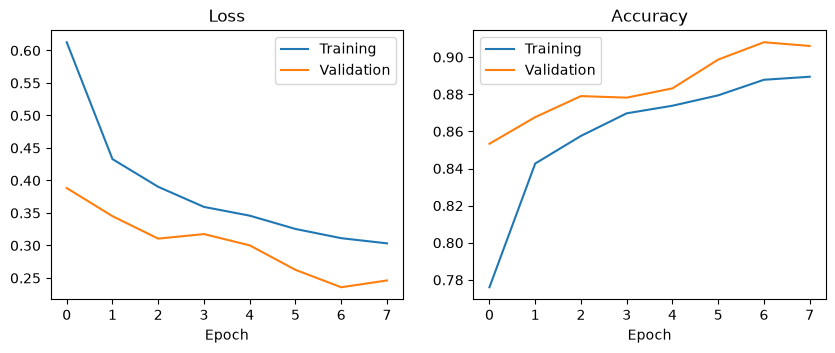

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(fashion_history["train_loss"], label="Training")
ax[0].plot(fashion_history["val_loss"], label="Validation")
ax[0].set_title("Loss")
ax[1].plot(fashion_history["train_acc"], label="Training")
ax[1].plot(fashion_history["val_acc"], label="Validation")
ax[1].set_title("Accuracy")
for a in ax:
    a.set_xlabel("Epoch")
    a.legend()
plt.show()

**Interpretation:** If train/validation curves stay close, the model is learning well without overfitting.

Validation checks generalization during training before final testing.

## 1.11 Testing

**Definition:** Testing means measuring the final model once on the test set, which was never used for training or for decisions. The test accuracy is the number we report as the performance of the model. We also look at the accuracy of every class and at precision, recall and F1-score.

**Example:** If the model classifies 9,200 of the 10,000 test images correctly, the test accuracy is 92 percent. Recall for a class is the share of that class that the model finds, and precision is the share of the images predicted as that class that are really that class.

**AI/ML Usage:** The held-out test set gives the number that is reported in papers, model cards and business reports. Teams also compute per-class metrics such as precision and recall, because different mistakes cost different amounts in real use (for example a missed disease against a false alarm).

In [10]:
def get_predictions(model, loader):
    model.eval()
    true, pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            scores = model(images.to(device))
            true.append(labels.numpy())
            pred.append(scores.argmax(dim=1).cpu().numpy())
    return np.concatenate(true), np.concatenate(pred)
fashion_test_loss, fashion_test_acc = evaluate(fashion_model, test_loader)
print("Test loss: %.4f | Test accuracy: %.2f percent" % (fashion_test_loss, fashion_test_acc * 100))
true, pred = get_predictions(fashion_model, test_loader)
per_class = pd.Series(pred == true).groupby(true).mean() * 100
per_class.index = class_names
print(per_class.round(1).sort_values())
print(classification_report(true, pred, target_names=class_names, digits=3, zero_division=0))

Test loss: 0.2574 | Test accuracy: 90.39 percent
Shirt          62.9
Pullover       85.4
Coat           87.6
T-shirt/top    89.5
Dress          92.8
Sneaker        95.4
Sandal         96.6
Ankle boot     96.9
Bag            98.3
Trouser        98.5
dtype: float64
              precision    recall  f1-score   support

 T-shirt/top      0.803     0.895     0.846      1000
     Trouser      0.994     0.985     0.989      1000
    Pullover      0.869     0.854     0.861      1000
       Dress      0.896     0.928     0.912      1000
        Coat      0.818     0.876     0.846      1000
      Sandal      0.988     0.966     0.977      1000
       Shirt      0.783     0.629     0.698      1000
     Sneaker      0.947     0.954     0.951      1000
         Bag      0.988     0.983     0.985      1000
  Ankle boot      0.949     0.969     0.959      1000

    accuracy                          0.904     10000
   macro avg      0.903     0.904     0.902     10000
weighted avg      0.903     0.90

**Interpretation:** Test accuracy should be near the best validation score; a large gap suggests overfitting.

## 1.12 Error Analysis

**Definition:** Error analysis means studying the mistakes of the model: which classes are confused with each other, and what the wrongly classified images look like. The main tool is the confusion matrix, a table where each row is the true class, each column is the predicted class, and each cell counts the images.

**Example:** If the cell (row `Shirt`, column `T-shirt/top`) contains 180, then 180 shirts were predicted as T-shirts. The numbers on the diagonal are the correct predictions.

**AI/ML Usage:** Error analysis is how practitioners decide what to do next: collect more data for a weak class, fix wrong labels, change the augmentation or try a different model. It is also used for model debugging, fairness checks and safety reviews before a model is deployed.

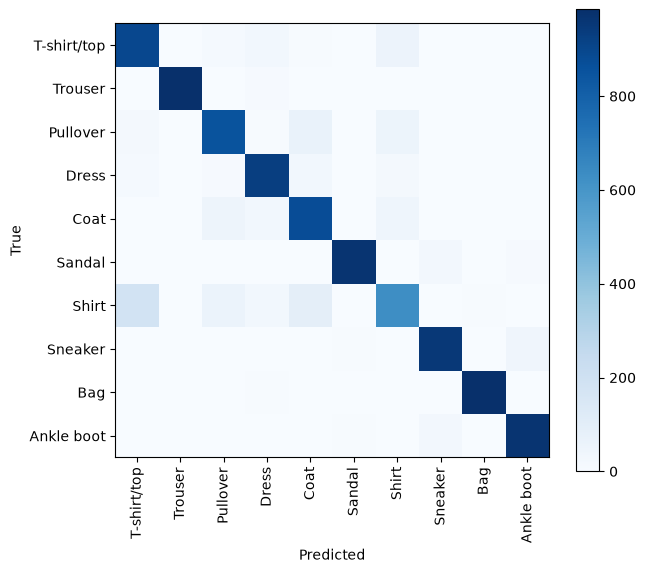

Shirt predicted as T-shirt/top : 184 times
Shirt predicted as Coat : 93 times
Pullover predicted as Coat : 68 times
Shirt predicted as Pullover : 60 times
T-shirt/top predicted as Shirt : 54 times
Wrong predictions: 961 out of 10000


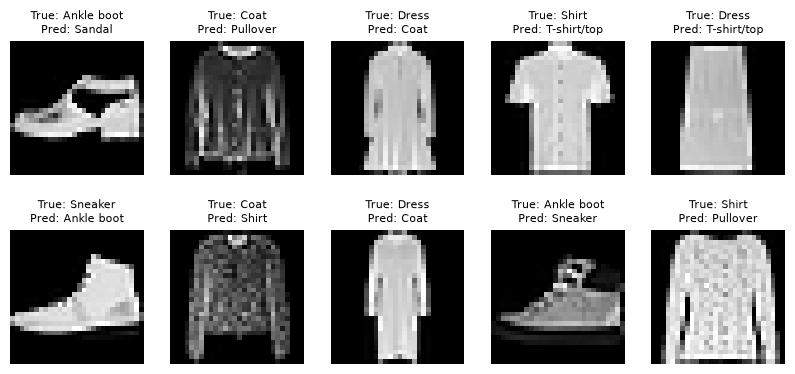

In [11]:
matrix = confusion_matrix(true, pred)
plt.figure(figsize=(7, 6))
plt.imshow(matrix, cmap="Blues")
plt.xticks(range(10), class_names, rotation=90)
plt.yticks(range(10), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()
pairs = [(class_names[i], class_names[j], matrix[i, j]) for i in range(10) for j in range(10) if i != j]
pairs = sorted(pairs, key=lambda p: p[2], reverse=True)
for true_name, pred_name, count in pairs[:5]:
    print(true_name, "predicted as", pred_name, ":", count, "times")
wrong = np.where(pred != true)[0]
print("Wrong predictions:", len(wrong), "out of", len(true))
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))
for a, index in zip(ax.flat, wrong[:10]):
    a.imshow(test_raw[index][0], cmap="gray")
    a.set_title("True: " + class_names[true[index]] + "\nPred: " + class_names[pred[index]], fontsize=8)
    a.axis("off")
plt.show()

**Interpretation:** A bright diagonal in the confusion matrix means correct predictions; off-diagonal cells show common mistakes.

# Part 2: A More Challenging Experiment with CIFAR-10

CIFAR-10 has 60,000 colour pictures (32 x 32 pixels) of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. There are 50,000 training images and 10,000 test images, with 6,000 images per class in total.

It is harder than Fashion-MNIST for several reasons: the images have colour, the background is different in every picture, the objects have different positions, angles and sizes, and some classes (cat and dog, for example) look very much alike at 32 x 32 pixels. We follow the same 12 steps, and in each topic we explain what is different from Part 1. The functions `evaluate`, `train_model` and `get_predictions` from Part 1 are reused.

## 2.1 Dataset Loading

**Definition:** The same idea as in Part 1: we get the images and labels with `torchvision.datasets`. This time the class is `datasets.CIFAR10`.

**Example:** `datasets.CIFAR10(root="data", train=True, download=True)` downloads the 50,000 training images (about 170 MB the first time).

**AI/ML Usage:** CIFAR-10 is one of the most used benchmarks for testing new CNN architectures, regularization methods and training tricks, before they are tried on much bigger datasets such as ImageNet.

In [12]:
cifar_train_raw = datasets.CIFAR10(root="data", train=True, download=True)
cifar_test_raw = datasets.CIFAR10(root="data", train=False, download=True)
cifar_names = cifar_train_raw.classes
print("Training images:", len(cifar_train_raw))
print("Test images:", len(cifar_test_raw))
print("Classes:", cifar_names)

100%|██████████| 170M/170M [38:31<00:00, 73.8kB/s]   


Training images: 50000
Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


**Interpretation:** The dataset has 50,000 training and 10,000 test RGB images across 10 classes.

## 2.2 Dataset Inspection

**Definition:** Again we check the size, shape, data type, pixel range and class counts, now for colour images.

**Example:** One CIFAR-10 image has the shape (32, 32, 3): 32 rows, 32 columns and 3 colour channels (red, green, blue).

**AI/ML Usage:** Inspecting colour data is the same standard check as before. In real projects it also finds channel problems, such as grayscale images mixed with colour images or images with a transparency channel, which would break the input layer of the network.

In [13]:
image, label = cifar_train_raw[0]
print("One sample type:", type(image).__name__, "| image size:", image.size, "| mode:", image.mode)
print("Label of the first image:", label, "->", cifar_names[label])
print("Data array shape:", tuple(cifar_train_raw.data.shape))
print("Data type:", cifar_train_raw.data.dtype)
print("Pixel value range:", cifar_train_raw.data.min().item(), "to", cifar_train_raw.data.max().item())
cifar_labels = torch.as_tensor(cifar_train_raw.targets).numpy()
print("Images per class:", np.bincount(cifar_labels))

One sample type: Image | image size: (32, 32) | mode: RGB
Label of the first image: 6 -> frog
Data array shape: (50000, 32, 32, 3)
Data type: uint8
Pixel value range: 0 to 255
Images per class: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


**Interpretation:** Images are 32x32 color tensors with 3 channels, and class counts are balanced.

 The class distribution is even, so accuracy is a fair summary of performance.

## 2.4 Image Visualization

**Definition:** Showing real CIFAR-10 images with their labels.

**Example:** The first training image of each class, in a grid of 2 rows and 5 columns.

**AI/ML Usage:** Looking at small natural images shows the limits of low resolution data. Teams use this to decide whether to collect higher resolution images or to start from a pretrained model, since small images carry less information.

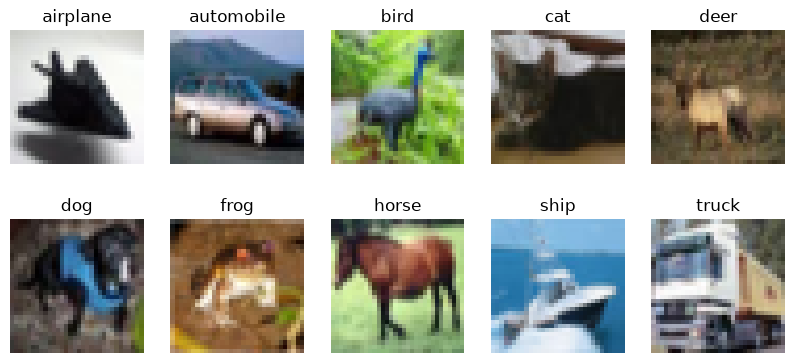

In [14]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))
for i, a in enumerate(ax.flat):
    index = int(np.where(cifar_labels == i)[0][0])
    a.imshow(cifar_train_raw[index][0])
    a.set_title(cifar_names[i])
    a.axis("off")
plt.show()

**Interpretation:** CIFAR-10 is harder because objects are less centered and backgrounds vary more.

Normalization makes feature values consistent across the three color channels.

 Augmentation adds variation so the model learns invariant patterns instead of memorizing.

## 2.7 DataLoader Creation

**Definition:** Same as in Part 1: we build the training, validation and test datasets with the right transforms, and wrap them in `DataLoader`s that deliver batches.

**Example:** One batch is a tensor of shape (128, 3, 32, 32) with 128 labels.

**AI/ML Usage:** In larger CIFAR-10 or ImageNet training, the same loaders use several worker processes (the `num_workers` option) to read and augment images in parallel with the computation of the GPU.

In [15]:
indices = torch.randperm(len(cifar_train_raw))
n_val = len(indices) // 10
train_idx, val_idx = indices[:-n_val], indices[-n_val:]
pixels = torch.as_tensor(cifar_train_raw.data)[train_idx].float() / 255
cifar_mean = pixels.mean(dim=(0, 1, 2)).tolist()
cifar_std = pixels.std(dim=(0, 1, 2)).tolist()
print("Channel means:", [round(m, 4) for m in cifar_mean])
print("Channel stds :", [round(s, 4) for s in cifar_std])
cifar_train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])
cifar_test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])
cifar_full_train = datasets.CIFAR10(root="data", train=True, transform=cifar_train_tf)
cifar_full_val = datasets.CIFAR10(root="data", train=True, transform=cifar_test_tf)
cifar_test_set = datasets.CIFAR10(root="data", train=False, transform=cifar_test_tf)
cifar_train_set = Subset(cifar_full_train, train_idx)
cifar_val_set = Subset(cifar_full_val, val_idx)
cifar_train_loader = DataLoader(cifar_train_set, batch_size=128, shuffle=True)
cifar_val_loader = DataLoader(cifar_val_set, batch_size=256)
cifar_test_loader = DataLoader(cifar_test_set, batch_size=256)
images, labels = next(iter(cifar_train_loader))
print("Training / validation / test images:", len(cifar_train_set), len(cifar_val_set), len(cifar_test_set))
print("One batch of images:", tuple(images.shape), "| labels:", tuple(labels.shape))

Channel means: [0.4911, 0.482, 0.4465]
Channel stds : [0.247, 0.2435, 0.2616]
Training / validation / test images: 45000 5000 10000
One batch of images: (128, 3, 32, 32) | labels: (128,)


**Interpretation:** The data loader creates 45,000 training, 5,000 validation, and 10,000 test samples in batches.

## 2.8 CNN Architecture

**Definition:** A deeper CNN than in Part 1: three convolution blocks (32, 64 and 128 kernels) with Batch Normalization, ReLU and Max Pooling, then Flatten, a fully connected layer with Dropout, and the output layer with 10 scores.

**Example:** The image (3, 32, 32) becomes 32 maps of 16 x 16, then 64 maps of 8 x 8, then 128 maps of 4 x 4, which Flatten turns into 128 x 4 x 4 = 2048 numbers.

**AI/ML Usage:** Stacking convolution blocks with a growing number of kernels (32, 64, 128) is the pattern used by classic networks such as VGG and ResNet. Real systems choose the depth by balancing accuracy against speed and memory.

In [16]:
cifar_model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 128), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(128, 10),
)
x = torch.zeros(1, 3, 32, 32)
for layer in cifar_model.eval():
    x = layer(x)
    print(layer.__class__.__name__.ljust(12), tuple(x.shape))
cifar_params = sum(p.numel() for p in cifar_model.parameters())
print("Learnable numbers:", cifar_params)

Conv2d       (1, 32, 32, 32)
BatchNorm2d  (1, 32, 32, 32)
ReLU         (1, 32, 32, 32)
MaxPool2d    (1, 32, 16, 16)
Conv2d       (1, 64, 16, 16)
BatchNorm2d  (1, 64, 16, 16)
ReLU         (1, 64, 16, 16)
MaxPool2d    (1, 64, 8, 8)
Conv2d       (1, 128, 8, 8)
BatchNorm2d  (1, 128, 8, 8)
ReLU         (1, 128, 8, 8)
MaxPool2d    (1, 128, 4, 4)
Flatten      (1, 2048)
Linear       (1, 128)
ReLU         (1, 128)
Dropout      (1, 128)
Linear       (1, 10)
Learnable numbers: 357258


**Interpretation:** The CNN reduces spatial size while increasing feature depth until it produces 10 class logits.

## 2.9 Training

**Definition:** The same training procedure as in Part 1, using the same `train_model` function: Adam optimizer, cross entropy loss, validation after each epoch, and the best weights kept.

**Example:** We train for 15 epochs. CIFAR-10 is harder, so it needs more epochs than Fashion-MNIST to learn.

**AI/ML Usage:** Reusing one training function for different datasets and models is standard practice. Real projects also add learning rate schedules, mixed precision training and experiment tracking tools to follow many training runs.

In [17]:
epochs = 15
start = time.time()
cifar_history = train_model(cifar_model, cifar_train_loader, cifar_val_loader, epochs)
cifar_time = time.time() - start
print("Training time: %.0f seconds" % cifar_time)

Epoch  1 | train loss 1.586, acc 0.415 | val loss 1.174, acc 0.572
Epoch  2 | train loss 1.281, acc 0.537 | val loss 1.063, acc 0.623
Epoch  3 | train loss 1.157, acc 0.590 | val loss 0.981, acc 0.646
Epoch  4 | train loss 1.063, acc 0.624 | val loss 0.878, acc 0.694
Epoch  5 | train loss 1.013, acc 0.644 | val loss 0.786, acc 0.719
Epoch  6 | train loss 0.966, acc 0.662 | val loss 0.780, acc 0.719
Epoch  7 | train loss 0.932, acc 0.675 | val loss 0.738, acc 0.738
Epoch  8 | train loss 0.897, acc 0.688 | val loss 0.690, acc 0.761
Epoch  9 | train loss 0.879, acc 0.695 | val loss 0.740, acc 0.739
Epoch 10 | train loss 0.847, acc 0.705 | val loss 0.678, acc 0.764
Epoch 11 | train loss 0.829, acc 0.712 | val loss 0.677, acc 0.762
Epoch 12 | train loss 0.806, acc 0.721 | val loss 0.651, acc 0.770
Epoch 13 | train loss 0.794, acc 0.725 | val loss 0.656, acc 0.776
Epoch 14 | train loss 0.773, acc 0.733 | val loss 0.647, acc 0.774
Epoch 15 | train loss 0.755, acc 0.740 | val loss 0.614, acc 0

**Interpretation:** This experiment is slower, especially on CPU; monitor training curves to confirm learning.

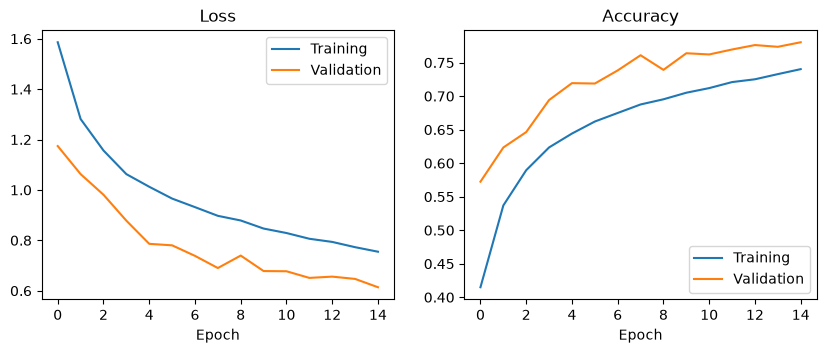

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(cifar_history["train_loss"], label="Training")
ax[0].plot(cifar_history["val_loss"], label="Validation")
ax[0].set_title("Loss")
ax[1].plot(cifar_history["train_acc"], label="Training")
ax[1].plot(cifar_history["val_acc"], label="Validation")
ax[1].set_title("Accuracy")
for a in ax:
    a.set_xlabel("Epoch")
    a.legend()
plt.show()

**Interpretation:** A small gap between train and validation curves is healthy; a large gap indicates overfitting.

 Validation helps choose the best model before final evaluation.

## 2.11 Testing

**Definition:** The final measurement of the CIFAR-10 model on the 10,000 test images, which were never used for training or decisions.

**Example:** The overall test accuracy, and the accuracy, precision and recall of each of the 10 classes.

**AI/ML Usage:** Benchmark datasets such as CIFAR-10 have a fixed test set, so that results from different research groups can be compared. In products, a similar fixed test set is used before each model release to check that the new model is not worse than the old one.

In [19]:
cifar_test_loss, cifar_test_acc = evaluate(cifar_model, cifar_test_loader)
print("Test loss: %.4f | Test accuracy: %.2f percent" % (cifar_test_loss, cifar_test_acc * 100))
cifar_true, cifar_pred = get_predictions(cifar_model, cifar_test_loader)
cifar_per_class = pd.Series(cifar_pred == cifar_true).groupby(cifar_true).mean() * 100
cifar_per_class.index = cifar_names
print(cifar_per_class.round(1).sort_values())
print(classification_report(cifar_true, cifar_pred, target_names=cifar_names, digits=3, zero_division=0))

Test loss: 0.6354 | Test accuracy: 78.04 percent
cat           54.6
bird          69.9
dog           75.4
deer          77.5
frog          79.8
horse         80.3
airplane      82.6
truck         83.5
ship          85.6
automobile    91.2
dtype: float64
              precision    recall  f1-score   support

    airplane      0.776     0.826     0.800      1000
  automobile      0.891     0.912     0.901      1000
        bird      0.675     0.699     0.687      1000
         cat      0.633     0.546     0.586      1000
        deer      0.752     0.775     0.764      1000
         dog      0.636     0.754     0.690      1000
        frog      0.840     0.798     0.818      1000
       horse      0.834     0.803     0.818      1000
        ship      0.904     0.856     0.879      1000
       truck      0.890     0.835     0.862      1000

    accuracy                          0.780     10000
   macro avg      0.783     0.780     0.781     10000
weighted avg      0.783     0.780     0.78

**Interpretation:** Test accuracy should match the best validation score; a large drop means poor generalization.

## 2.12 Error Analysis

**Definition:** Studying the mistakes: the confusion matrix, the most common confusions, and examples of wrongly classified images.

**Example:** If many images of `cat` are predicted as `dog` and many `dog` as `cat`, the model cannot separate this pair well.

**AI/ML Usage:** On CIFAR-10 type tasks, error analysis shows whether to use a deeper model, more augmentation or a pretrained model. In applications such as autonomous driving or medical imaging, the most dangerous confusions are studied in detail before deployment.

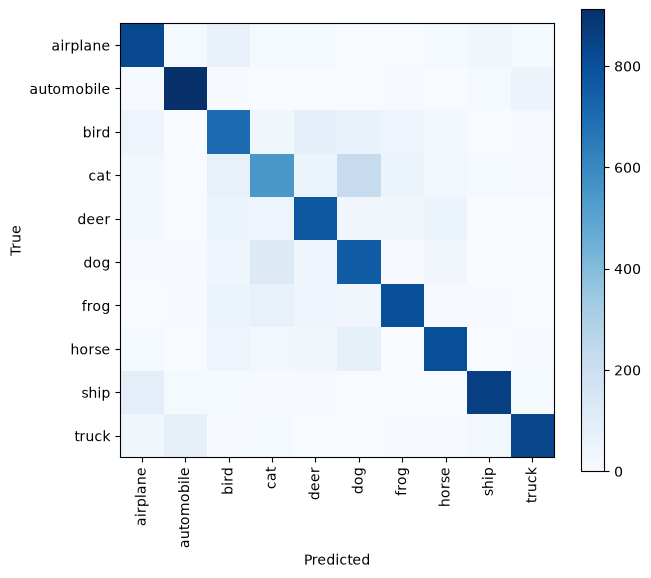

cat predicted as dog : 221 times
dog predicted as cat : 117 times
ship predicted as airplane : 89 times
bird predicted as deer : 82 times
horse predicted as dog : 76 times
Wrong predictions: 2196 out of 10000


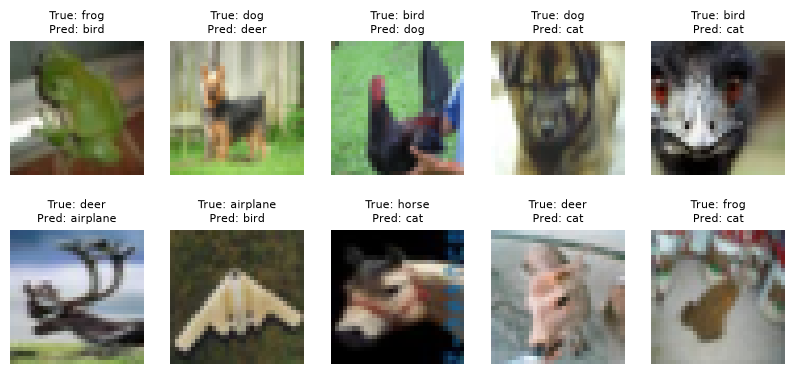

In [20]:
cifar_matrix = confusion_matrix(cifar_true, cifar_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cifar_matrix, cmap="Blues")
plt.xticks(range(10), cifar_names, rotation=90)
plt.yticks(range(10), cifar_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()
pairs = [(cifar_names[i], cifar_names[j], cifar_matrix[i, j]) for i in range(10) for j in range(10) if i != j]
pairs = sorted(pairs, key=lambda p: p[2], reverse=True)
for true_name, pred_name, count in pairs[:5]:
    print(true_name, "predicted as", pred_name, ":", count, "times")
wrong = np.where(cifar_pred != cifar_true)[0]
print("Wrong predictions:", len(wrong), "out of", len(cifar_true))
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))
for a, index in zip(ax.flat, wrong[:10]):
    a.imshow(cifar_test_raw[index][0])
    a.set_title("True: " + cifar_names[cifar_true[index]] + "\nPred: " + cifar_names[cifar_pred[index]], fontsize=8)
    a.axis("off")
plt.show()

**Interpretation:** The confusion matrix shows which classes are often confused, especially similar-looking objects.

# Part 3: Comparing the Two Experiments

## 3.1 Fashion-MNIST vs CIFAR-10

**Definition:** A side-by-side table of the two experiments: the size of the input, the size of the model, the training time and the validation and test accuracy.

**Example:** The table is built from the variables that we saved in the two parts, so it shows the numbers of your own run.

**AI/ML Usage:** Comparing experiments in a table is how teams keep track of which model, dataset and settings gave which result (experiment tracking). It also shows the trade-off between accuracy, training time and model size when a model is chosen for production.

In [21]:
comparison = pd.DataFrame({
    "Dataset": ["Fashion-MNIST", "CIFAR-10"],
    "Input shape": ["1 x 28 x 28", "3 x 32 x 32"],
    "Epochs": [len(fashion_history["val_acc"]), len(cifar_history["val_acc"])],
    "Parameters": [fashion_params, cifar_params],
    "Training time (s)": [round(fashion_time), round(cifar_time)],
    "Best validation acc (%)": [round(max(fashion_history["val_acc"]) * 100, 1), round(max(cifar_history["val_acc"]) * 100, 1)],
    "Test acc (%)": [round(fashion_test_acc * 100, 1), round(cifar_test_acc * 100, 1)],
})
print(comparison.to_string(index=False))

      Dataset Input shape  Epochs  Parameters  Training time (s)  Best validation acc (%)  Test acc (%)
Fashion-MNIST 1 x 28 x 28       8      421834                458                     90.8          90.4
     CIFAR-10 3 x 32 x 32      15      357258               1599                     78.0          78.0


**Interpretation:** Fashion-MNIST is easier and usually scores higher; CIFAR-10 is harder and typically performs lower.